## Experiment 03

We reproduce an observation that certain words appear in sentences more often as a specific neuron activates more, or appear less often the more that neuron activates. In other words, the frequency of the word is monotonically decreasing or increasing with activation.

The first step will be to extract the vocabulary of all tokens that appear more than 100 times in each of the four datasets, as per the authors' methodology. To that end, we want to save the tokenized sentences somewhere first.

In [55]:
from transformers import AutoTokenizer

# load the tokenizer for bert
bert_tokenizer = AutoTokenizer.from_pretrained('google-bert/bert-base-uncased')

In [56]:
import numpy as np
import pandas as pd
from collections import Counter
from scipy.sparse import csr_matrix, save_npz

# we make a sparse token occurence count matrix
for ds_name in ['qqp', 'qnli', 'wiki', 'books']:
    # read dataset
    df = pd.read_parquet(f'../../../datasets/{ds_name}.parquet')
    # get the sentences from it
    sents = df['txt'].tolist()

    # collect data in a sparse matrix (scipy csr_matrix)
    # occurences[sentence=row[k], token=col[k]] = val[k]
    row, col, val = [], [], []

    for idx, sent in enumerate(sents):
        # tokenize each sentence
        tok = bert_tokenizer(sent, truncation=True, add_special_tokens=False)
        tok = tok['input_ids']
        # count each token id with a Counter
        cnt = Counter(tok)
        # append data to the matrix
        # for row: sentence idx, repeated for each unique token
        row.extend([idx for _ in range(len(cnt))])
        # for col: append each unique token
        col.extend(cnt.keys())
        # for val: how many times each unique token occurs
        val.extend(cnt.values())

    # create the sparse matrix
    M = csr_matrix((val, (row, col)),
                   shape=(len(df), bert_tokenizer.vocab_size),
                   dtype=np.int32)
    
    # save it
    save_npz(f'../../../tokenized/datasets/{ds_name}_tok.npz', M)

Now we've saved the tokenized sentences for further use. We construct the vocabulary:

In [57]:
from scipy.sparse import load_npz

# mask of valid tokens, initially all 1/True
mask = np.ones(bert_tokenizer.vocab_size, bool)

# for each dataset
for ds_name in ['qqp', 'qnli', 'wiki', 'books']:
    # load the tokenized sentences
    npz = load_npz(f'../../../tokenized/datasets/{ds_name}_tok.npz')
    # sum on columns to obtain token counts
    csum = np.asarray(npz.sum(0)).ravel()
    # mask off, keeping only the token ids that had >=100
    mask &= (csum >= 100)

# after we finish, look at nonzero entries in the mask
# they correspond to tokens clearing >=100 in all datasets
vocab = np.flatnonzero(mask)

# save it
np.save('../../../tokenized/vocab.npy', vocab)
# let's compare with the original authors' result
print(f'Our frequent tokens: {len(vocab)}, original authors: 915')

Our frequent tokens: 828, original authors: 915


Now we look at these 828 tokens across the neurons of BERT to find monotonicity.

In [58]:
# m = vocabulary size
# n = bert last-layer neuron count
m, n = len(vocab), 768

# for each (dataset, neuron idx, token id) tuple: is it inc/dec?
# initially all zeroes, we fill this in by iterating through the datasets
inc = np.zeros((4, n, m), bool)
dec = np.zeros((4, n, m), bool)

for idx, ds_name in enumerate(['qqp', 'qnli', 'wiki', 'books']):
    # load .npz file
    npz = load_npz(f'../../../tokenized/datasets/{ds_name}_tok.npz')
    # restore the sparse matrix from it
    M = npz.tocsc()[:, vocab].tocsr()
    # load the sentence embeddings = neuron activations on the last layer
    embed = np.asarray(np.load(f'../../../embeds/full/{ds_name}_embed.npy'))

    for neur_idx in range(n):
        # from the entire embed, look at the activations of the neur_idx neuron
        activations = np.argsort(embed[:, neur_idx])

        counts = np.vstack([np.array(M[qtl].sum(0)).ravel()             # sums counts over quintiles
                            for qtl in np.array_split(activations, 5)]) # splits into quintiles
        
        # forward finite differences
        delta = np.diff(counts, axis=0)
        # update inc and dec now
        # on dataset idx, neur_idx is inc if all differences have the same positive sign
        inc[idx, neur_idx] = (delta > 0).all(0)
        # analogously, it's decreasing if all of the signs of the differences are negative
        dec[idx, neur_idx] = (delta < 0).all(0)

    # free some memory
    del embed

# save monotonicity data
np.save('../../../tokenized/mono_inc.npy', inc)
np.save('../../../tokenized/mono_dec.npy', dec)

In [59]:
from itertools import combinations

# uncomment if you haven't ran the previous cells
# inc = np.load('../../../tokenized/mono_inc.npy')
# dec = np.load('../../../tokenized/mono_dec.npy')

# monotone = either increasing or decreasing
# this isn't saved anywhere, create it here
mon = inc | dec

# dataset names
ds_names = ['qqp', 'qnli', 'wiki', 'books']
# collect table rows here
tab = []

# need all combinations of datasets
# n=4, range over from k=1 to k=4
for k in range(1, 5):
    # k choices from [0, 1, 2, 3] = dataset indexes
    for Cnk in combinations(range(4), k):
        # indexes of used datasets
        # 0=qqp, 1=qnli, 2=wiki, 3=books
        used_datasets = list(Cnk)
        # add entry to table
        tab.append({
            'Datasets': ','.join(ds_names[ds] for ds in used_datasets),
            'Monotonic':  f'{(mon[used_datasets].all(0).mean() * 100):.2f}%',
            'Increasing': f'{(inc[used_datasets].all(0).mean() * 100):.2f}%',
            'Decreasing': f'{(dec[used_datasets].all(0).mean() * 100):.2f}%',
        })

# turn the table into a dataframe
tab = pd.DataFrame(tab)
tab

,Datasets,Monotonic,Increasing,Decreasing
0,qqp,25.85%,12.86%,12.99%
1,qnli,19.56%,9.71%,9.85%
2,wiki,30.30%,15.01%,15.28%
3,books,25.17%,12.57%,12.60%
4,"qqp,qnli",6.53%,2.75%,2.77%
5,"qqp,wiki",9.55%,3.99%,4.06%
6,"qqp,books",8.14%,3.40%,3.41%
7,"qnli,wiki",10.75%,5.27%,5.36%
8,"qnli,books",6.11%,2.41%,2.43%
9,"wiki,books",9.43%,3.92%,3.96%


For the sake of producing an example similar to the one offered by the authors, we look at tokens `windows` and `months`, and their activations for neurons 235 and 721.

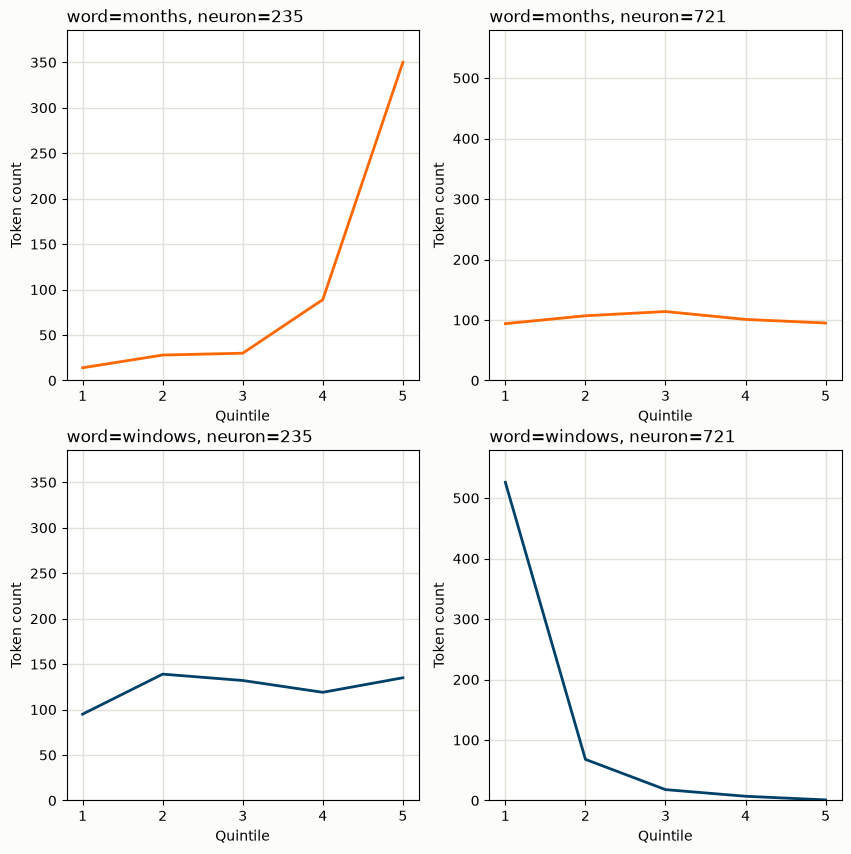

In [60]:
import matplotlib.pyplot as plt

# the example we considered
W = ['months', 'windows']
N = [235, 721]

# colors for the graph
word_col = { 'months':  '#ff6700', 
             'windows': '#00416a' }

bg = '#fcfcfb'

# load npz data
# both examples are in qqp, and the original authors
# also used examples in qqp for the example Figure 6
npz = load_npz('../../../tokenized/datasets/qqp_tok.npz')
# construct the matrix
M = npz.tocsc()
# get the embeds
embed = np.load('../../../embeds/full/qqp_embed.npy', mmap_mode='r')

# neuron activation data for 235 and 721 split in quintiles
quintiles = {n: np.array_split(np.argsort(embed[:, n]), 5) for n in N}

# count occurences of 'months' and 'windows'
counts = {w: np.array(
                M[:, bert_tokenizer.convert_tokens_to_ids(w)].todense()
            ).ravel()
            for w in W}

# (word, neuron): [array with 5 entries = token count for each quintile]
# qc = (for each) quintile (the) counts 
qc = {(w, n): [counts[w][qtl].sum() for qtl in quintiles[n]]
              for w in W 
              for n in N}

# mapping neuron index to highest token count
# we scale both the subplot with monotonicity and the one with no patern
ylim = {n: max(                 
               max(qc[(w, n)])  # across all quintiles, find the maximum value
               for w in W)      # across all the words activating the neuron,
                                # take the highest max-across-quintiles
            for n in N}         # do this for each neuron

# 2x2 subplots, so 4 total plots
fig, axes = plt.subplots(2, 2, figsize=(10, 10), facecolor=bg)

# for each subplot, corresponding to word w on neuron n
for ax, (w, n) in zip(axes.flat, qc):
    # plot activations
    ax.plot([1, 2, 3, 4, 5],    # x-axis = quintiles
            qc[(w, n)],         # y-axis = activations
            color=word_col[w],  # style options...
            linewidth=2,
            markersize=8, 
            markeredgecolor=bg, 
            markeredgewidth=2)
    
    # enable background (axis below)
    ax.set_axisbelow(True)
    # draw x-axis grid
    ax.grid(axis='x', color='#e1e0d9', linewidth=1)
    # draw y-axis grid
    ax.grid(axis='y', color='#e1e0d9', linewidth=1)

    # y-axis limit slightly larder
    # otherwise graph touches border box
    ax.set_ylim(0, ylim[n] * 1.1)
    # set title
    ax.set_title(f'word={w}, neuron={n}', loc='left')
    # set x-ticks corresponding to the quintile
    # 1=0-20%, 2=20-40%, 3=40-60%, 4=60-80%, 5=80-100%
    ax.set_xticks([1, 2, 3, 4, 5])
    # label the axes
    ax.set_xlabel('Quintile')
    ax.set_ylabel('Token count')

# show the plot
plt.show()